# Operator-learning comparison: kernel vs. neural

Combines the kernel-method results (`Framework{1,2}/results_*_no_pca*.csv`) with the neural-operator
comparison CSV from `run_comparison.py` into one table, so the kernelMO frameworks sit next to the
four neural settings (DeepONet no-coeff, DeepONet coeff-concat, MIONet, MNO).

Split matches across both families (first-N, no shuffle): Framework2 = 10000/4000, Framework1 = 80/20.
Out-of-distribution rows are keyed by the OOD file (`ood_file`), so the parametric PDEs — which ship
only variant OOD files like `ood_par_scale.h5` — are covered too. Test (in-distribution) error comes
from the base `_no_pca.csv`; OOD error from the `_all_ood.csv` kernel files.

In [11]:
import glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = os.path.abspath('..')          # notebook lives in neural_network_experiments/
RESULTS_CSV = 'results_comparison.csv'     # produced by run_comparison.py

SETTING_ORDER = [
    'Kernel (vanilla)', 'Kernel (kernelMO)',
    'DeepONet (no coeff)', 'DeepONet (coeff concat)', 'MIONet', 'MNO',
]
COLS = ['framework', 'pde', 'setting', 'size', 'split', 'ood_file',
        'mean_relative_error', 'train_time_seconds', 'predict_time_seconds', 'n_params']

def normalize_pde(name):
    """Join key so e.g. Framework2 'Param_wave' and kernel 'Param_Wave' align."""
    return str(name).lower()

## Load the neural-operator results

In [12]:
neural = pd.read_csv(RESULTS_CSV)
if 'size' not in neural.columns:
    neural['size'] = 'medium'
if 'ood_file' not in neural.columns:
    neural['ood_file'] = ''
neural['ood_file'] = neural['ood_file'].fillna('')
neural['pde'] = neural['pde'].map(normalize_pde)
neural = neural[COLS]
print('settings:', sorted(neural.setting.unique()))
print('sizes:', sorted(neural['size'].dropna().unique()))
print('neural ood files:', sorted(neural.loc[neural.split=='ood','ood_file'].unique()))
neural.head()

settings: ['DeepONet (coeff concat)', 'DeepONet (no coeff)', 'MIONet', 'MNO']
sizes: ['large', 'medium', 'small']
neural ood files: ['ood.h5', 'ood_init.h5', 'ood_init_GP.h5', 'ood_init_amp.h5', 'ood_matern.h5', 'ood_par.h5', 'ood_par_init.h5', 'ood_par_init_GP.h5', 'ood_par_init_amp.h5', 'ood_par_kernel.h5', 'ood_par_scale.h5', 'ood_par_var.h5', 'ood_scale.h5', 'ood_var.h5']


,framework,pde,setting,size,split,ood_file,mean_relative_error,train_time_seconds,predict_time_seconds,n_params
0,Framework2,conservation_law,MIONet,small,test,,0.112057,248.572759,0.384499,306601
1,Framework2,conservation_law,MIONet,small,ood,ood.h5,0.131810,248.572759,0.335414,306601
2,Framework2,conservation_law,MIONet,small,ood,ood_init_GP.h5,0.152478,248.572759,0.339852,306601
3,Framework2,conservation_law,MIONet,small,ood,ood_init_amp.h5,0.298077,248.572759,0.340087,306601
4,Framework2,conservation_law,MIONet,small,ood,ood_par.h5,0.131810,248.572759,0.338660,306601


## Load and tidy the kernel-method results

Test error from `results_*_no_pca.csv`; OOD error from `results_*_no_pca_all_ood.csv` (keyed by
`ood_filename`). For each PDE / method / split / ood-file we keep the best (lowest-error) kernel
variant (RBF vs. Matern). `vanilla` -> *Kernel (vanilla)*; `product_gpr`/`framework1` -> *Kernel (kernelMO)*.

In [13]:
METHOD_LABEL = {'vanilla': 'Kernel (vanilla)', 'product_gpr': 'Kernel (kernelMO)', 'framework1': 'Kernel (kernelMO)'}
BASE_GLOBS = {
    'Framework2': 'Framework2/results_*_sample_no_pca.csv',
    'Framework1': 'Framework1/results_*_parameter_set_no_pca.csv',
}
OOD_GLOBS = {
    'Framework2': 'Framework2/results_*_sample_no_pca_all_ood.csv',
    'Framework1': 'Framework1/results_*_parameter_set_no_pca_all_ood.csv',
}

def _read(globs):
    frames = []
    for fw, pat in globs.items():
        for path in glob.glob(os.path.join(REPO_ROOT, pat)):
            df = pd.read_csv(path)
            df['framework'] = fw
            frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def load_kernel_results():
    out = []
    # in-distribution test
    base = _read(BASE_GLOBS)
    if not base.empty:
        b = base[(base.method.isin(METHOD_LABEL)) & (base.split == 'test')].copy()
        b['setting'] = b['method'].map(METHOD_LABEL)
        b['pde'] = b['pde'].map(normalize_pde)
        b['ood_file'] = ''
        idx = b.groupby(['framework', 'pde', 'setting'])['mean_relative_error'].idxmin()
        out.append(b.loc[idx])
    # out-of-distribution (keyed by ood_filename)
    allood = _read(OOD_GLOBS)
    if not allood.empty:
        o = allood[(allood.method.isin(METHOD_LABEL)) & (allood.split == 'ood')].copy()
        o['setting'] = o['method'].map(METHOD_LABEL)
        o['pde'] = o['pde'].map(normalize_pde)
        o['ood_file'] = o['ood_filename'].fillna('ood.h5')
        idx = o.groupby(['framework', 'pde', 'setting', 'ood_file'])['mean_relative_error'].idxmin()
        out.append(o.loc[idx])
    if not out:
        return pd.DataFrame(columns=COLS)
    k = pd.concat(out, ignore_index=True)
    k['size'] = np.nan
    k['n_params'] = np.nan
    for c in ['train_time_seconds', 'predict_time_seconds']:
        if c not in k.columns:
            k[c] = np.nan
    return k[COLS]

kernel = load_kernel_results()
print('kernel ood files:', sorted(kernel.loc[kernel.split=='ood','ood_file'].unique()))
kernel.head()

kernel ood files: ['ood.h5', 'ood_init.h5', 'ood_init_GP.h5', 'ood_init_amp.h5', 'ood_matern.h5', 'ood_par.h5', 'ood_par_init.h5', 'ood_par_init_GP.h5', 'ood_par_init_amp.h5', 'ood_par_kernel.h5', 'ood_par_scale.h5', 'ood_par_var.h5', 'ood_scale.h5', 'ood_var.h5']


,framework,pde,setting,size,split,ood_file,mean_relative_error,train_time_seconds,predict_time_seconds,n_params
0,Framework1,conservation_law,Kernel (kernelMO),NaN,test,,0.000145,0.493360,0.062403,NaN
1,Framework1,conservation_law,Kernel (vanilla),NaN,test,,0.037187,6.175974,0.798259,NaN
2,Framework1,diffreacadv,Kernel (kernelMO),NaN,test,,0.003845,0.479843,0.061032,NaN
3,Framework1,diffreacadv,Kernel (vanilla),NaN,test,,0.120020,5.855176,0.750113,NaN
4,Framework1,nonlinear_klein_gordon,Kernel (kernelMO),NaN,test,,0.002089,0.493203,0.073475,NaN


In [14]:
combined = pd.concat([kernel, neural], ignore_index=True)
sizes_present = sorted(neural['size'].dropna().unique())
combined.head()

,framework,pde,setting,size,split,ood_file,mean_relative_error,train_time_seconds,predict_time_seconds,n_params
0,Framework1,conservation_law,Kernel (kernelMO),NaN,test,,0.000145,0.493360,0.062403,NaN
1,Framework1,conservation_law,Kernel (vanilla),NaN,test,,0.037187,6.175974,0.798259,NaN
2,Framework1,diffreacadv,Kernel (kernelMO),NaN,test,,0.003845,0.479843,0.061032,NaN
3,Framework1,diffreacadv,Kernel (vanilla),NaN,test,,0.120020,5.855176,0.750113,NaN
4,Framework1,nonlinear_klein_gordon,Kernel (kernelMO),NaN,test,,0.002089,0.493203,0.073475,NaN



## In-distribution test error (kernel vs. neural)

When several network sizes are present, the best (lowest-error) size is shown per neural setting.

In [15]:
def ordered(p):
    return p[[c for c in SETTING_ORDER if c in p.columns]]

test = combined[combined['split'] == 'test']
test_pivot = ordered(test.pivot_table(index=['framework', 'pde'], columns='setting',
                                      values='mean_relative_error', aggfunc='min'))
test_pivot.style.format('{:.3e}')

## Out-of-distribution error, by OOD file

One row per (framework, PDE, `ood_file`). The standard PDEs use `ood.h5`; the parametric PDEs use
their variant files. Empty cells mean that method/PDE has no result for that OOD file.

In [16]:
ood = combined[combined['split'] == 'ood']
if ood.empty:
    print('no ood rows')
else:
    ood_pivot = ordered(ood.pivot_table(index=['framework', 'pde', 'ood_file'], columns='setting',
                                        values='mean_relative_error', aggfunc='min'))
    display(ood_pivot.style.format('{:.3e}'))

## Bar charts per framework

Grouped bars (log scale). Test uses in-distribution error; OOD shows one representative file per PDE
(`ood.h5` if present, else the first available variant).

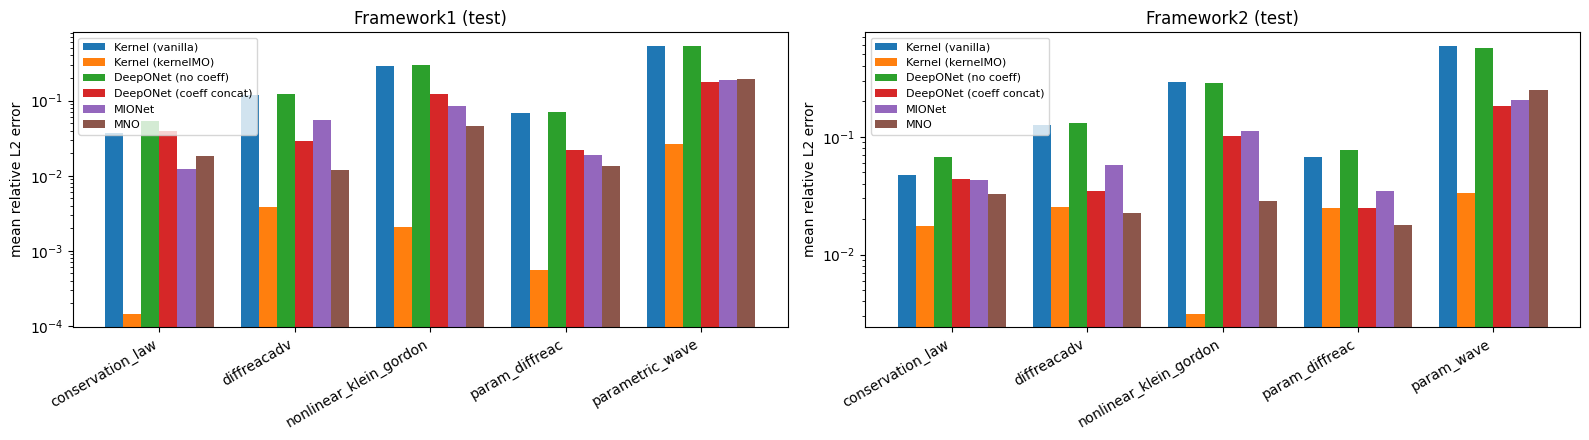

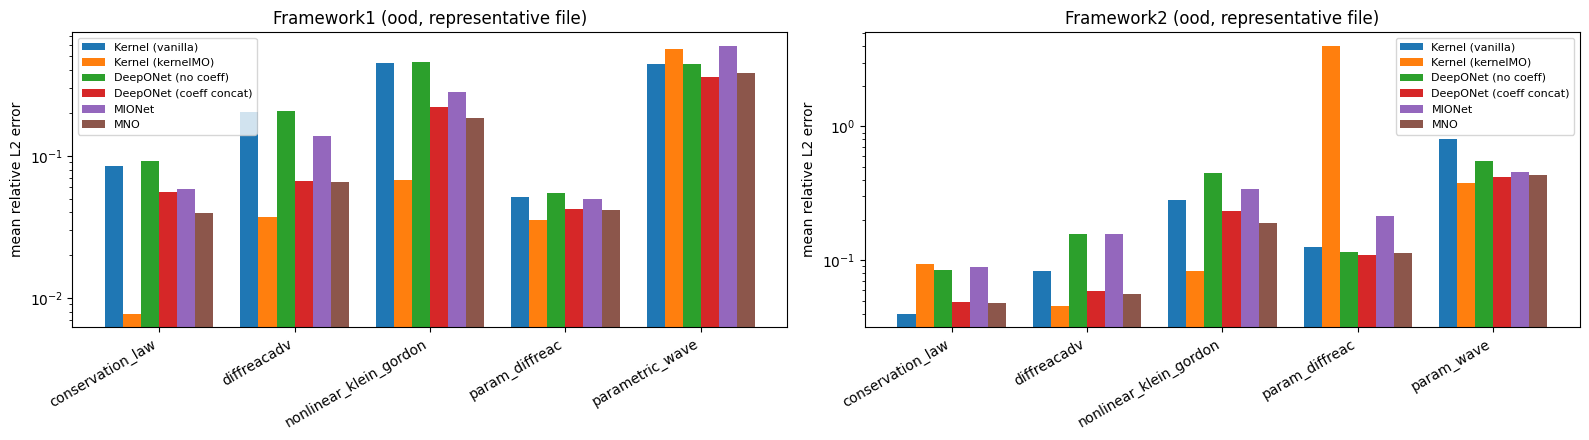

In [17]:
def representative_ood(df):
    """One OOD row per (framework, pde): prefer ood.h5, else first file alphabetically.
    Uses a merge instead of groupby.apply so the grouping columns survive (pandas 3.0
    drops grouping columns from the apply result)."""
    def pick_file(files):
        files = sorted(set(files))
        return 'ood.h5' if 'ood.h5' in files else files[0]
    chosen = (df.groupby(['framework', 'pde'])['ood_file']
                .agg(pick_file).rename('_chosen').reset_index())
    m = df.merge(chosen, on=['framework', 'pde'])
    return m[m['ood_file'] == m['_chosen']].drop(columns='_chosen')

def bar(sub, title):
    frameworks = sorted(sub['framework'].unique())
    fig, axes = plt.subplots(1, len(frameworks), figsize=(8 * len(frameworks), 4.5), squeeze=False)
    for ax, fw in zip(axes[0], frameworks):
        p = ordered(sub[sub.framework == fw].pivot_table(index='pde', columns='setting',
                                                         values='mean_relative_error', aggfunc='min'))
        pdes = list(p.index); x = np.arange(len(pdes)); cols = list(p.columns)
        width = 0.8 / max(len(cols), 1)
        for i, c in enumerate(cols):
            ax.bar(x + i * width, p[c].values, width, label=c)
        ax.set_yscale('log'); ax.set_xticks(x + width * (len(cols) - 1) / 2)
        ax.set_xticklabels(pdes, rotation=30, ha='right')
        ax.set_title(f'{fw} ({title})'); ax.set_ylabel('mean relative L2 error'); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

bar(test, 'test')
if not ood.empty:
    bar(representative_ood(ood), 'ood, representative file')

## Training and inference time

`train_time_seconds` (kernel = fit time; neural = full training run) and `predict_time_seconds`
(time to predict the test split). Inference time is directly comparable; training time is not
(single solve vs. many epochs). Neural rows use the medium size unless only one size was run.

In [18]:
ref_size = 'medium' if 'medium' in sizes_present else (sizes_present[0] if sizes_present else None)
tt = test[test['size'].isna() | (test['size'] == ref_size)]
print('neural size =', ref_size)
print('\nInference time on the test split (seconds):')
display(ordered(tt.pivot_table(index=['framework', 'pde'], columns='setting',
                               values='predict_time_seconds', aggfunc='min')).style.format('{:.3f}'))
print('Training time (seconds):')
display(ordered(tt.pivot_table(index=['framework', 'pde'], columns='setting',
                               values='train_time_seconds', aggfunc='min')).style.format('{:.2f}'))

neural size = medium

Inference time on the test split (seconds):


Training time (seconds):


## Model size (trainable parameters)

Parameter count per model and size (neural models only; kernel methods have no trainable
parameters). MNO uses its own per-size preset: medium == paper MNO-S, large == paper MNO-L.

In [19]:
# Trainable parameters by model and size, in millions (constant across PDEs/splits).
SIZE_ORDER = ['small', 'medium', 'large']
psize = neural.pivot_table(index='setting', columns='size', values='n_params', aggfunc='max')
cols = [s for s in SIZE_ORDER if s in psize.columns]
rows = [s for s in SETTING_ORDER if s in psize.index]
psize = psize.reindex(rows)[cols]
display((psize / 1e6).style.format('{:.2f}M'))

size,small,medium,large
setting,,,
DeepONet (no coeff),0.29M,2.15M,9.48M
DeepONet (coeff concat),0.31M,2.17M,9.53M
MIONet,0.32M,2.22M,9.73M
MNO,0.60M,1.22M,16.70M


## Network-size sweep (neural only)

Only meaningful when `run_comparison.py --sizes small medium large` was used. Shows how error and
training/inference time scale with parameter count, averaged over PDEs.

size,small,medium,large
setting,,,
DeepONet (coeff concat),1.002e-01,8.476e-02,1.053e-01
DeepONet (no coeff),2.267e-01,2.251e-01,2.271e-01
MIONet,1.188e-01,9.567e-02,1.775e-01
MNO,1.251e-01,9.743e-02,6.406e-02


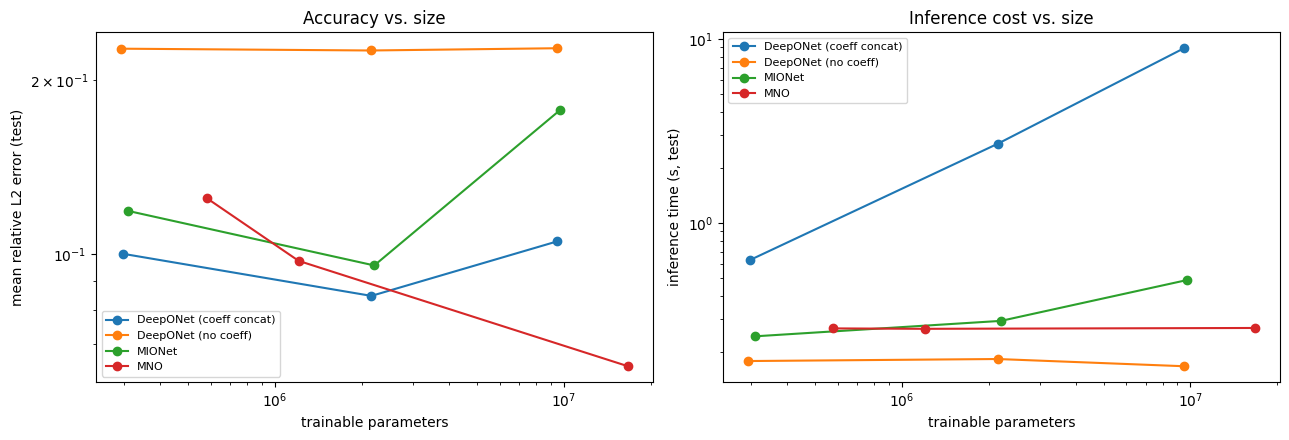

In [20]:
SIZE_ORDER = ['small', 'medium', 'large']
n_test = neural[neural['split'] == 'test'].copy()
if n_test['size'].nunique() <= 1:
    print('Only one network size present — rerun with `--sizes small medium large` to populate this section.')
else:
    order = [s for s in SIZE_ORDER if s in n_test['size'].unique()]
    summary = (n_test.groupby(['setting', 'size'])
               .agg(mean_rel_err=('mean_relative_error', 'mean'),
                    n_params=('n_params', 'mean'),
                    train_s=('train_time_seconds', 'mean'),
                    predict_s=('predict_time_seconds', 'mean'))
               .reset_index())
    display(summary.pivot(index='setting', columns='size', values='mean_rel_err')[order].style.format('{:.3e}'))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for setting, g in summary.groupby('setting'):
        g = g.set_index('size').reindex(order).reset_index()
        axes[0].plot(g['n_params'], g['mean_rel_err'], 'o-', label=setting)
        axes[1].plot(g['n_params'], g['predict_s'], 'o-', label=setting)
    for ax, ylab in zip(axes, ['mean relative L2 error (test)', 'inference time (s, test)']):
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlabel('trainable parameters'); ax.set_ylabel(ylab); ax.legend(fontsize=8)
    axes[0].set_title('Accuracy vs. size'); axes[1].set_title('Inference cost vs. size')
    plt.tight_layout(); plt.show()